# Chromatin PTR analysis
April 2, 2024

Goal: Analyse the peak to trough ratio of the chromatin for all genes. 

*Questions:*
- Is the peak to trough ratio calculation appropriate?
- What is the distribution of the bins? (to check the psuedo count values)


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [171]:
from src.peak_to_trough_anaysis import PeakToTroughAnalysis

ptr_dir = 'output/deconvolve_combined_g_opt_2024_03_14/chromatin_ptr_fix_eps_1/'
peak_to_trough_analysis_eps1 = PeakToTroughAnalysis(ptr_dir)
peak_to_trough_analysis_eps1.compute_summary_metrics()


In [173]:
chromatin_dir = 'output/deconvolve_combined_g_opt_2024_03_14/chromatin/'
peak_to_trough_analysis_eps1.load_f_files(chromatin_dir)

1/5575 - 00:00:00.333
1001/5575 - 00:00:14.690
2001/5575 - 00:00:23.223
3001/5575 - 00:00:33.371
4001/5575 - 00:00:41.886
5001/5575 - 00:00:50.540


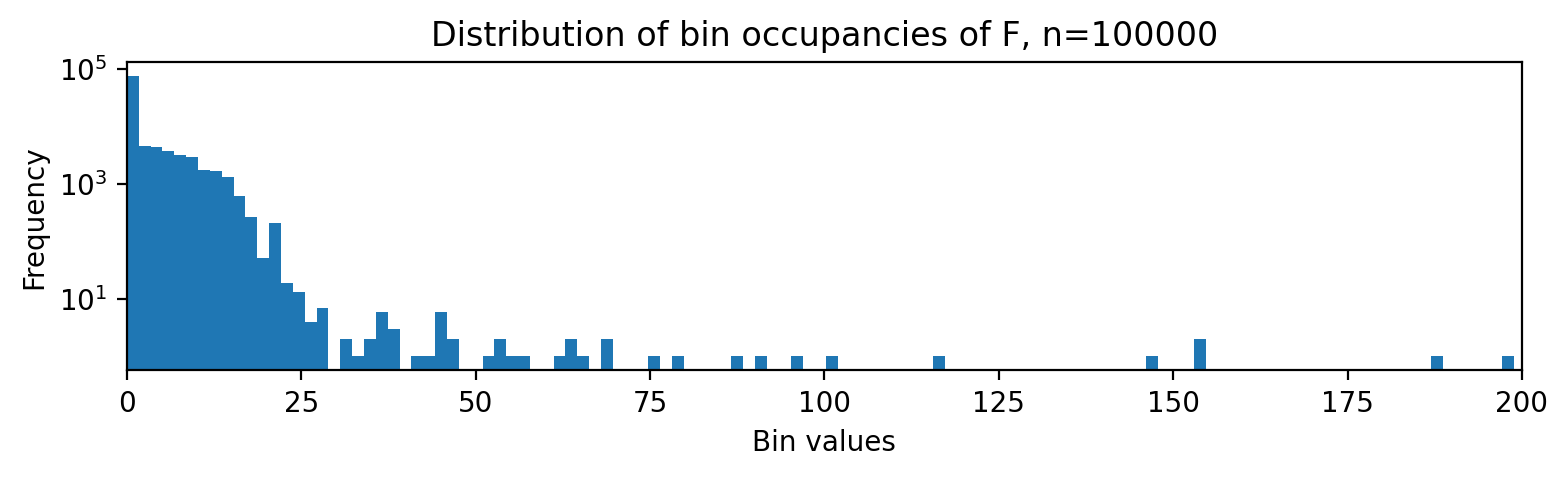

In [177]:
peak_to_trough_analysis_eps1.plot_f_bin_histogram()

In [178]:
from src.peak_to_trough_anaysis import PeakToTroughAnalysis

# Load the updated epsilon = 0.01 ptrs
ptr_dir = 'output/deconvolve_combined_g_opt_2024_03_14/chromatin_ptr_fix_2_eps_01/'
peak_to_trough_analysis_eps01 = PeakToTroughAnalysis(ptr_dir)
peak_to_trough_analysis_eps01.compute_summary_metrics()


In [214]:
raw_g_ptrs_eps1_directory = 'output/raw_g_ptrs_old'
raw_g_ptrs_eps01_directory = 'output/raw_g_ptrs_eps_01/'

In [221]:
peak_to_trough_analysis_eps1.load_raw_data_ptrs(raw_g_ptrs_eps01_directory)
peak_to_trough_analysis_eps1.raw_joined_metrics_df.head(2)

,mean_raw_replicates,deconvolved_ptr
orf_name,,
YAL067W-A,19.146220,1.169257
YAL067C,8.263246,1.404367


In [203]:

def plot_comparison_between_raw_deconvolved(ptr_analysis):
    """Temporary function to compare raw and deconvolved PTRs, we have a more
    substantial plotting function elsewhere"""
    
    from scipy.stats import pearsonr

    plot_data = ptr_analysis.raw_joined_metrics_df.dropna()

    x, y = plot_data.mean_raw_replicates, plot_data.deconvolved_ptr

    plt.scatter(x, y, s=1)

    print(pearsonr(x, y))


In [218]:
# Load the updated epsilon = 0.1 ptrs
ptr_dir = 'output/deconvolve_combined_g_opt_2024_03_14/chromatin_ptr_fix_eps_01/'
#peak_to_trough_analysis_01 = PeakToTroughAnalysis(ptr_dir)
#peak_to_trough_analysis_01.compute_summary_metrics()
peak_to_trough_analysis_01.load_raw_data_ptrs(raw_g_ptrs_eps01_directory)

In [219]:
# Load the updated epsilon = 0.01 ptrs
ptr_dir = 'output/deconvolve_combined_g_opt_2024_03_14/chromatin_ptr_fix_eps_001/'
#peak_to_trough_analysis_001 = PeakToTroughAnalysis(ptr_dir)
#peak_to_trough_analysis_001.compute_summary_metrics()
peak_to_trough_analysis_001.load_raw_data_ptrs(raw_g_ptrs_eps01_directory)

PearsonRResult(statistic=-0.5085896664239122, pvalue=0.0)
PearsonRResult(statistic=-0.3448822307989022, pvalue=1.7508882194479856e-155)
PearsonRResult(statistic=-0.10624466390026674, pvalue=1.8117340218278393e-15)


Text(0.5, 0.98, 'Comparison between Deconvolved PTR pseudocounts, Raw=1')

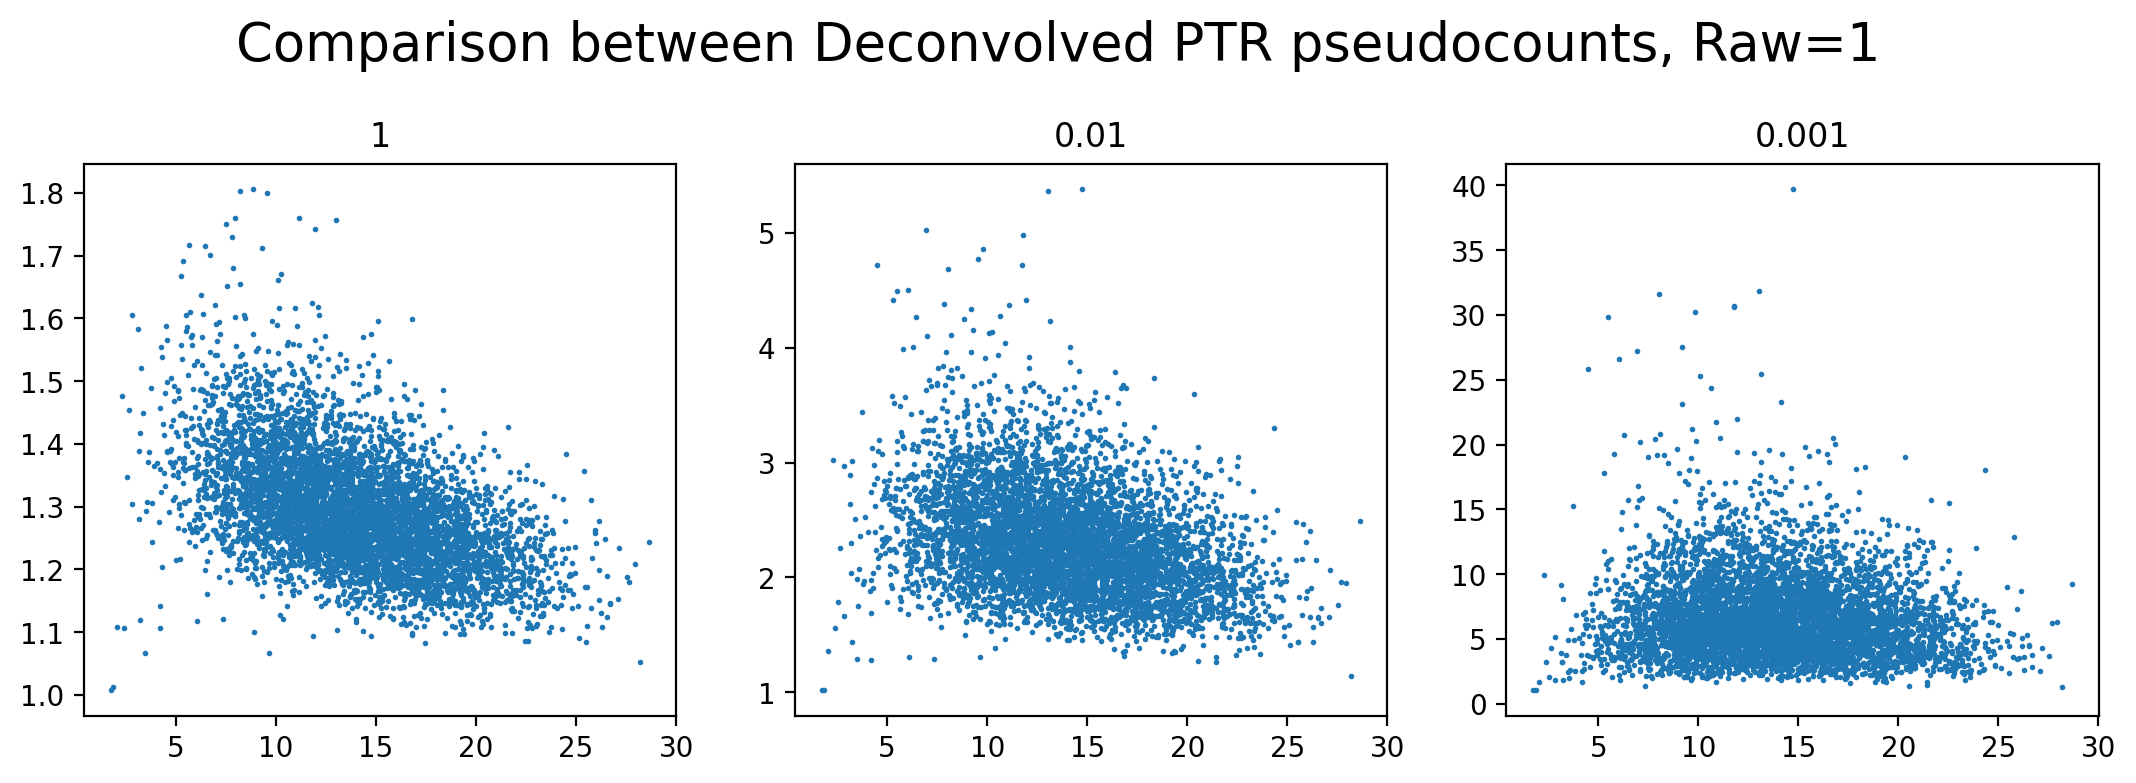

In [222]:
plt.figure(figsize=(13, 4))
plt.subplots_adjust(top=0.8)

plt.subplot(1, 3, 1)
plot_comparison_between_raw_deconvolved(peak_to_trough_analysis_eps1)
plt.title("1")

plt.subplot(1, 3, 2)
plot_comparison_between_raw_deconvolved(peak_to_trough_analysis_01)
plt.title("0.01")

plt.subplot(1, 3, 3)
plot_comparison_between_raw_deconvolved(peak_to_trough_analysis_001)
plt.title("0.001")

plt.suptitle("Comparison between Deconvolved PTR pseudocounts, Raw=1", 
             fontsize=19)

In [225]:
peak_to_trough_analysis_01.raw_joined_metrics_df.sort_values('mean_raw_replicates')

,mean_raw_replicates,deconvolved_ptr
orf_name,,
YHR055C,1.728833,1.018862
YHR054C,1.862924,1.015165
YIL015W,2.049645,1.360022
YPL056C,2.298596,3.021978
YBR118W,2.381959,1.562992
...,...,...
YOR330C,27.535537,1.762512
YML102W,27.670557,1.962025
YLL021W,27.938678,1.947889
